# Intermittent demand

Intermittent demand is *sparse*: long runs of zeros punctuated by occasional nonzero orders — the reality for spare parts and slow-moving SKUs. Standard forecasters trained on smooth series fail here, which makes this generator the test bed for Croston-type methods and zero-inflated models.

::: {.callout-note}
## The model

$$y_t = b_t \cdot z_t, \qquad b_t \sim \mathrm{Bernoulli}(p), \qquad z_t \sim \text{size distribution}$$

Nonzero demands are separated by random gaps, with order sizes drawn independently. `intermittent_pattern` shapes *when* orders occur — `random`, `clustered` (bursts of demand), or `seasonal` (periodic demand windows).
:::

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import IntermittentDemandGenerator

## 1. Occurrence pattern

`intermittent_pattern` decides *when* demand happens, holding the size distribution fixed. Random gives i.i.d. Bernoulli periods, clustered groups them into runs, and seasonal concentrates them in recurring windows.


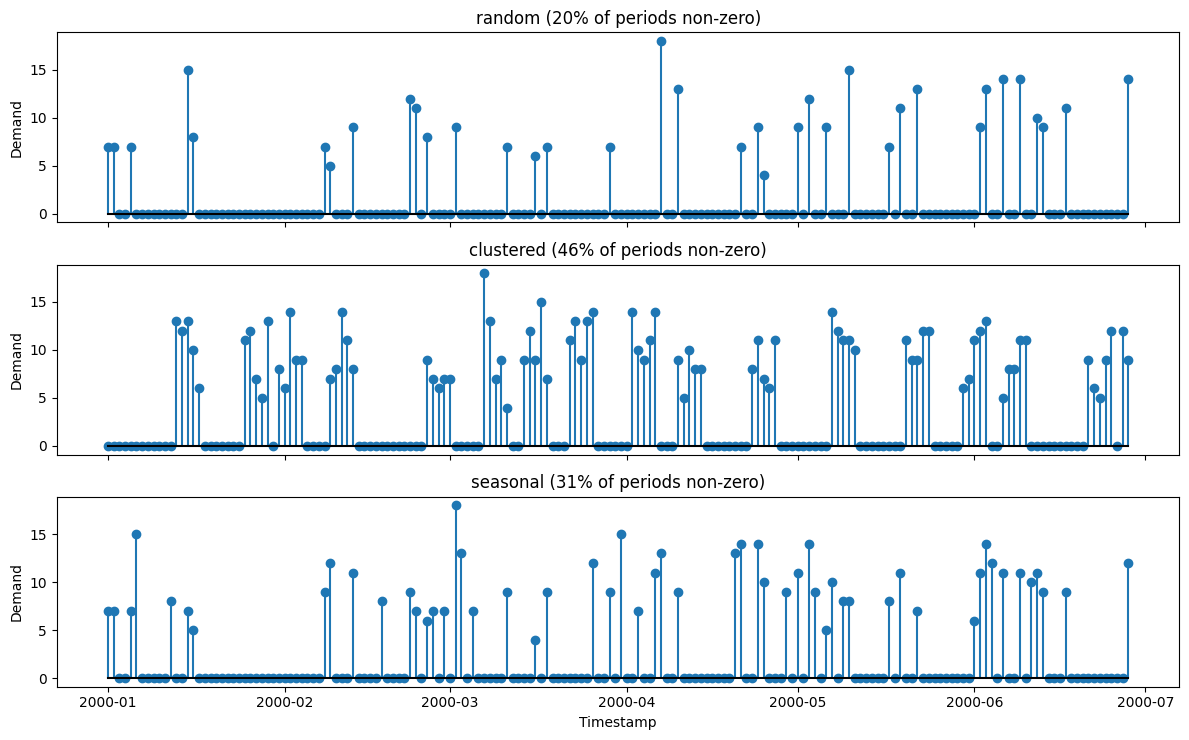

In [ ]:
random_df = IntermittentDemandGenerator(
    engine="polars", min_length=180, max_length=180, freq="D",
    demand_probability=0.2, demand_distribution="poisson", demand_mean=10.0,
    intermittent_pattern="random", seed=42,
).generate(n_series=1)

clustered_df = IntermittentDemandGenerator(
    engine="polars", min_length=180, max_length=180, freq="D",
    demand_probability=0.2, demand_distribution="poisson", demand_mean=10.0,
    intermittent_pattern="clustered", cluster_size=5, seed=42,
).generate(n_series=1)

seasonal_df = IntermittentDemandGenerator(
    engine="polars", min_length=180, max_length=180, freq="D",
    demand_probability=0.2, demand_distribution="poisson", demand_mean=10.0,
    intermittent_pattern="seasonal", seasonal_period=30, seed=42,
).generate(n_series=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
panels = [("random", random_df), ("clustered", clustered_df), ("seasonal", seasonal_df)]
for ax, (label, df) in zip(axes, panels):
    values = df["y"].to_list()
    nonzero = sum(1 for value in values if value > 0)
    ax.stem(df["ds"].to_list(), values, linefmt="C0-", markerfmt="C0o", basefmt="k-")
    ax.set(ylabel="Demand", title=f"{label} ({nonzero / len(values):.0%} of periods non-zero)")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. Demand size distributions

Compare Poisson, negative binomial, lognormal, and gamma distributions for demand sizes.

In [ ]:
distributions = ["poisson", "negative_binomial", "lognormal", "gamma"]
results = {}

for dist in distributions:
    params = {
        "min_length": 300,
        "max_length": 300,
        "freq": "D",
        "demand_probability": 0.3,
        "demand_distribution": dist,
        "demand_mean": 7.0,
        "demand_std": 3.0,
        "seed": 789,
    }

    gen = IntermittentDemandGenerator(engine="polars", **params)
    df = gen.generate(n_series=1)

    non_zero = df.filter(pl.col("y") > 0)["y"].to_numpy()
    if len(non_zero) > 0:
        results[dist] = {
            "count": len(non_zero),
            "mean": non_zero.mean(),
            "std": non_zero.std(),
            "min": non_zero.min(),
            "max": non_zero.max(),
        }

print(f"Distribution comparison (when demand > 0):")
print(f"{'Distribution':<20} {'Count':<8} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8}")
print("-" * 60)
for dist, stats in results.items():
    print(
        f"{dist:<20} {stats['count']:<8} {stats['mean']:<8.2f} {stats['std']:<8.2f} {stats['min']:<8.0f} {stats['max']:<8.0f}"
    )

Distribution comparison (when demand > 0):
Distribution         Count    Mean     Std      Min      Max     
------------------------------------------------------------
poisson              86       6.80     2.48     3        15      
negative_binomial    86       6.43     2.82     1        15      
lognormal            86       6.55     2.62     2        18      
gamma                86       6.47     2.73     1        17      


## 3. Bulk orders

Simulate rare but large orders with a minimum order quantity constraint.

In [ ]:
params_bulk = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "demand_probability": 0.1,
    "demand_distribution": "gamma",
    "demand_mean": 50.0,
    "demand_std": 20.0,
    "min_demand": 20,
    "seed": 999,
}

gen_bulk = IntermittentDemandGenerator(engine="polars", **params_bulk)
df_bulk = gen_bulk.generate(n_series=1)

print(f"Generated {len(df_bulk)} daily observations")
print(f"Minimum order quantity: {params_bulk['min_demand']}")

non_zero_bulk = df_bulk.filter(pl.col("y") > 0)["y"].to_numpy()
if len(non_zero_bulk) > 0:
    print(f"\nBulk order statistics:")
    print(f"  Number of orders: {len(non_zero_bulk)}")
    print(f"  Mean order size:  {non_zero_bulk.mean():.2f}")
    print(f"  Min order size:   {non_zero_bulk.min():.0f}")
    print(f"  Max order size:   {non_zero_bulk.max():.0f}")
    print(f"  All orders >= minimum: {np.all(non_zero_bulk >= params_bulk['min_demand'])}")

df_bulk.head(20)

Generated 200 daily observations
Minimum order quantity: 20

Bulk order statistics:
  Number of orders: 24
  Mean order size:  50.34
  Min order size:   24
  Max order size:   92
  All orders >= minimum: True


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,36.316717
"""0""",2000-01-02 00:00:00,0.0
"""0""",2000-01-03 00:00:00,54.317364
"""0""",2000-01-04 00:00:00,0.0
"""0""",2000-01-05 00:00:00,0.0
…,…,…
"""0""",2000-01-16 00:00:00,0.0
"""0""",2000-01-17 00:00:00,0.0
"""0""",2000-01-18 00:00:00,0.0


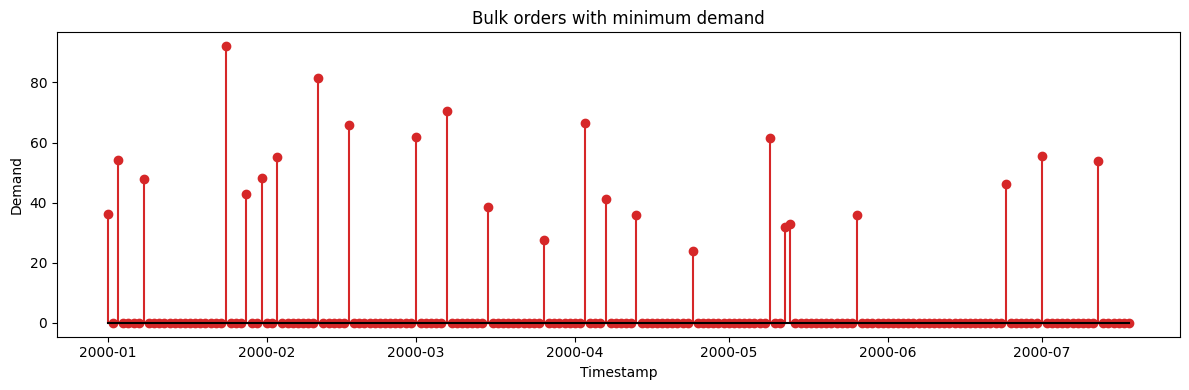

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
series = df_bulk.filter(pl.col("unique_id") == "0")
ax.stem(series["ds"].to_list(), series["y"].to_list(), linefmt="C3-", markerfmt="C3o", basefmt="k-")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Demand")
ax.set_title("Bulk orders with minimum demand")
plt.tight_layout()
plt.show()

## 4. Multiple series

Generate multiple independent intermittent demand series and compare their statistics.

In [ ]:
params_multi = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "demand_probability": 0.25,
    "demand_distribution": "poisson",
    "demand_mean": 6.0,
    "seed": 1234,
}

gen_multi = IntermittentDemandGenerator(engine="polars", **params_multi)
df_multi = gen_multi.generate(n_series=3)

print(f"Generated 3 intermittent demand series")
print(f"Total rows: {len(df_multi)}")
print(f"Unique series IDs: {df_multi['unique_id'].unique().to_list()}")

series_stats = (
    df_multi.group_by("unique_id")
    .agg(
        [
            (pl.col("y") == 0).sum().alias("zero_days"),
            (pl.col("y") > 0).sum().alias("demand_days"),
            pl.col("y").sum().alias("total_demand"),
            pl.col("y")
            .filter(pl.col("y") > 0)
            .mean()
            .alias("avg_demand_when_nonzero"),
        ]
    )
    .sort("unique_id")
)
series_stats

Generated 3 intermittent demand series
Total rows: 300
Unique series IDs: ['0', '1', '2']


unique_id,zero_days,demand_days,total_demand,avg_demand_when_nonzero
cat,u32,u32,f64,f64
"""0""",83,17,82.0,4.823529
"""1""",78,22,142.0,6.454545
"""2""",69,31,167.0,5.387097


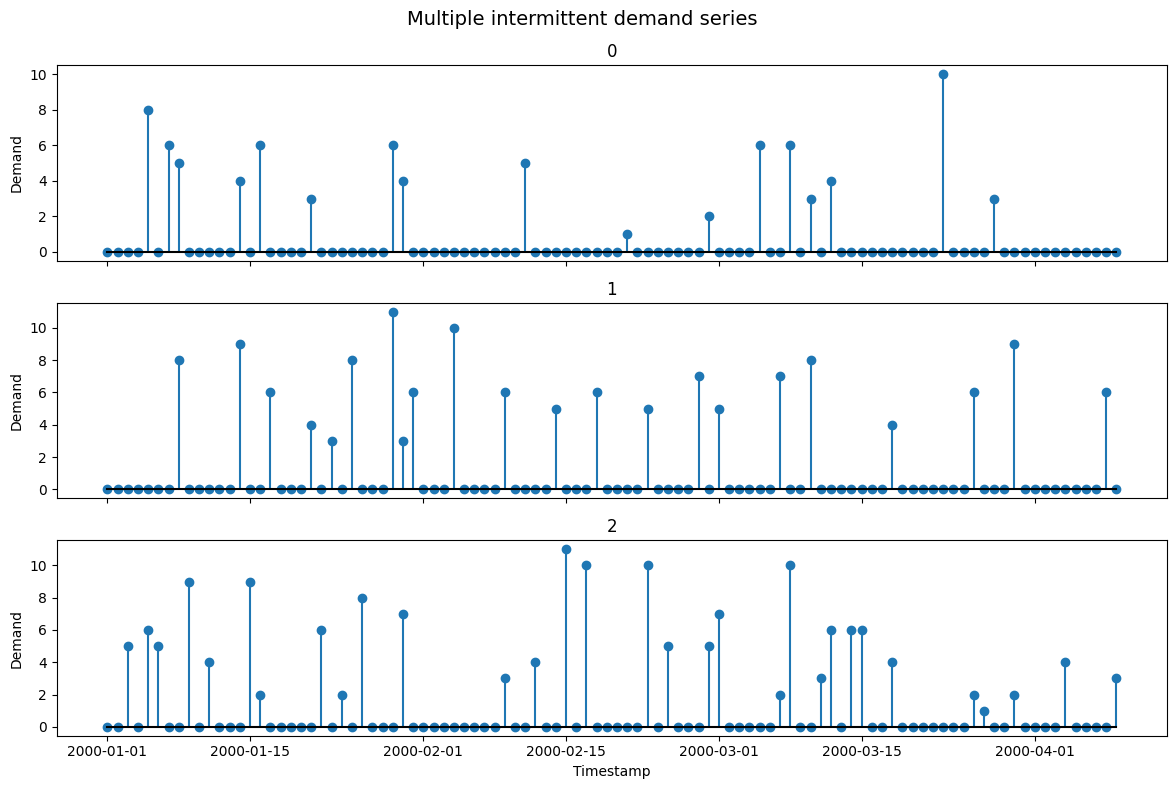

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, uid in zip(axes, df_multi["unique_id"].unique().to_list()):
    series = df_multi.filter(pl.col("unique_id") == uid)
    ax.stem(series["ds"].to_list(), series["y"].to_list(), linefmt="C0-", markerfmt="C0o", basefmt="k-")
    ax.set_ylabel("Demand")
    ax.set_title(uid)
axes[-1].set_xlabel("Timestamp")
plt.suptitle("Multiple intermittent demand series", fontsize=14)
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [INAR](../statistical/inar) — autocorrelated integer counts.
- [Poisson process](../stochastic/poisson_process) — event arrivals over time.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::